In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
!unzip /content/porter.zip


unzip:  cannot find or open /content/porter.zip, /content/porter.zip.zip or /content/porter.zip.ZIP.


In [3]:
df = pd.read_csv("porter.csv")
df.head()



,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0


In [4]:
print(df.shape)

(197428, 14)


In [5]:
print(df.dtypes)

market_id                   float64
created_at                   object
actual_delivery_time         object
store_id                     object
store_primary_category       object
order_protocol              float64
total_items                   int64
subtotal                      int64
num_distinct_items            int64
min_item_price                int64
max_item_price                int64
total_onshift_partners      float64
total_busy_partners         float64
total_outstanding_orders    float64
dtype: object


In [6]:
df.describe()

,market_id,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
count,196441.000000,196433.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,181166.000000,181166.000000,181166.000000
mean,2.978706,2.882352,3.196391,2682.331402,2.670791,686.218470,1159.588630,44.808093,41.739747,58.050065
std,1.524867,1.503771,2.666546,1823.093688,1.630255,522.038648,558.411377,34.526783,32.145733,52.661830
min,1.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000
25%,2.000000,1.000000,2.000000,1400.000000,1.000000,299.000000,800.000000,17.000000,15.000000,17.000000
50%,3.000000,3.000000,3.000000,2200.000000,2.000000,595.000000,1095.000000,37.000000,34.000000,41.000000
75%,4.000000,4.000000,4.000000,3395.000000,3.000000,949.000000,1395.000000,65.000000,62.000000,85.000000
max,6.000000,7.000000,411.000000,27100.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000


In [7]:
df.describe(include=object)

,created_at,actual_delivery_time,store_id,store_primary_category
count,197428,197421,197428,192668
unique,180985,178110,6743,74
top,2015-01-24 01:56:33,2015-02-01 03:44:13,d43ab110ab2489d6b9b2caa394bf920f,american
freq,6,5,937,19399


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 196441 non-null  float64
 1   created_at                197428 non-null  object 
 2   actual_delivery_time      197421 non-null  object 
 3   store_id                  197428 non-null  object 
 4   store_primary_category    192668 non-null  object 
 5   order_protocol            196433 non-null  float64
 6   total_items               197428 non-null  int64  
 7   subtotal                  197428 non-null  int64  
 8   num_distinct_items        197428 non-null  int64  
 9   min_item_price            197428 non-null  int64  
 10  max_item_price            197428 non-null  int64  
 11  total_onshift_partners    181166 non-null  float64
 12  total_busy_partners       181166 non-null  float64
 13  total_outstanding_orders  181166 non-null  f

In [9]:
df.isna().sum()

,0
market_id,987
created_at,0
actual_delivery_time,7
store_id,0
store_primary_category,4760
order_protocol,995
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0


In [10]:
(df.isna().sum()/len(df))*100

,0
market_id,0.499929
created_at,0.000000
actual_delivery_time,0.003546
store_id,0.000000
store_primary_category,2.411006
order_protocol,0.503981
total_items,0.000000
subtotal,0.000000
num_distinct_items,0.000000
min_item_price,0.000000


In [11]:
df['market_id'].value_counts()

,count
market_id,
2.0,55058
4.0,47599
1.0,38037
3.0,23297
5.0,18000
6.0,14450


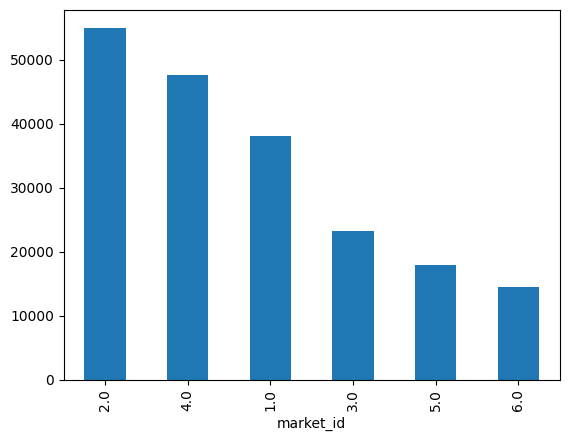

In [12]:
df['market_id'].value_counts().plot(kind='bar')
plt.show()

In [13]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['market_id', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_partners', 'total_busy_partners',
       'total_outstanding_orders'],
      dtype='object')

In [14]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['created_at', 'actual_delivery_time', 'store_id',
       'store_primary_category'],
      dtype='object')

In [15]:
data=df[num_cols]

In [16]:
data.skew()

,0
market_id,0.361200
order_protocol,0.137093
total_items,21.413824
subtotal,1.961501
num_distinct_items,1.591479
min_item_price,2.331280
max_item_price,2.201033
total_onshift_partners,0.860758
total_busy_partners,0.782463
total_outstanding_orders,1.195322


array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>]], dtype=object)

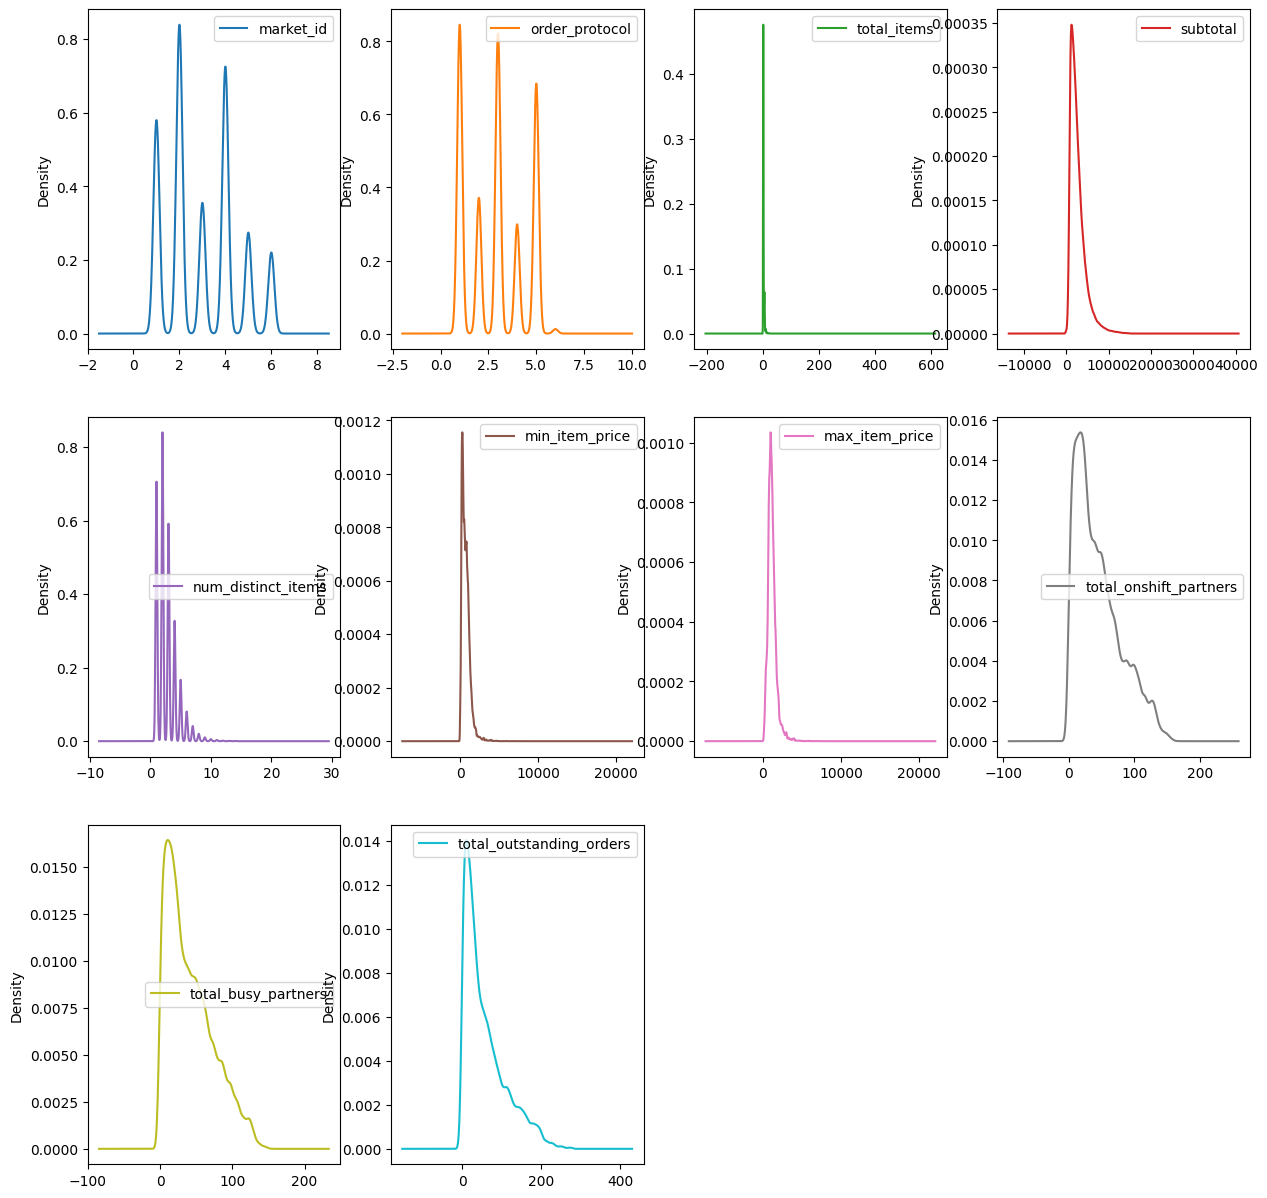

In [17]:
data.plot(
    kind="kde",
    sharex=False,
    subplots=True,
    layout=(3, 4),
    figsize=(15, 15)
)

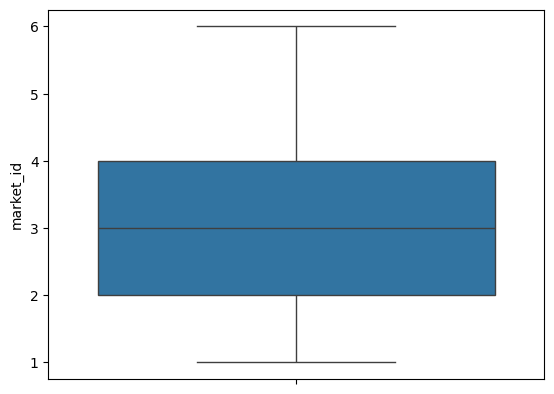

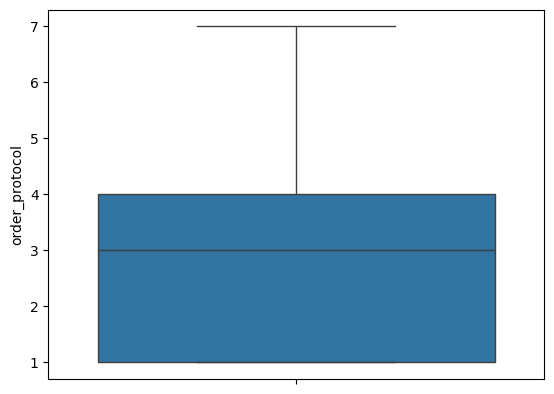

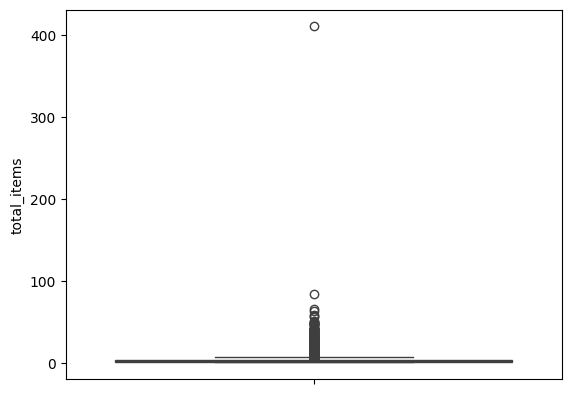

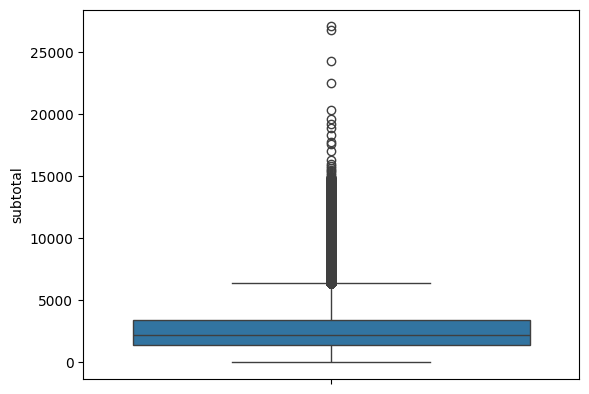

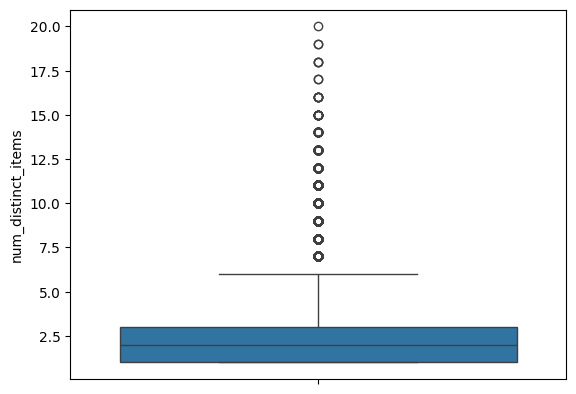

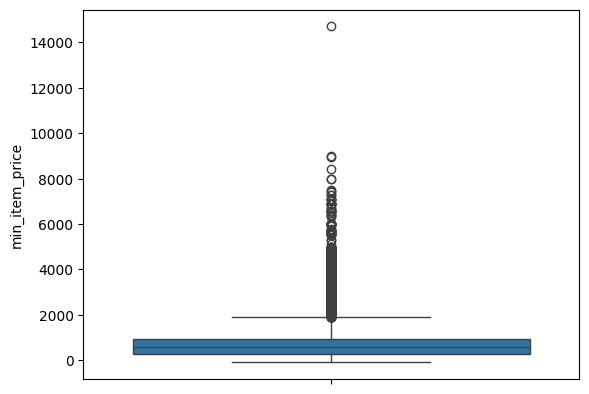

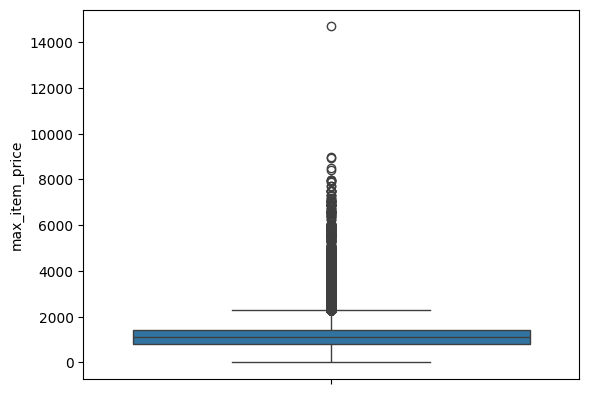

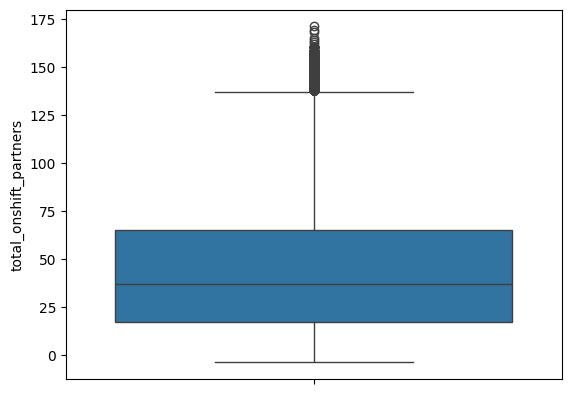

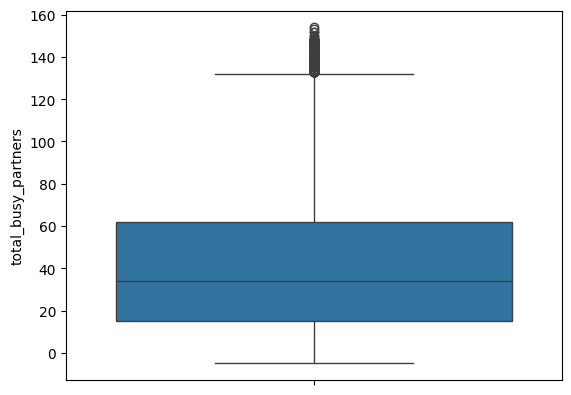

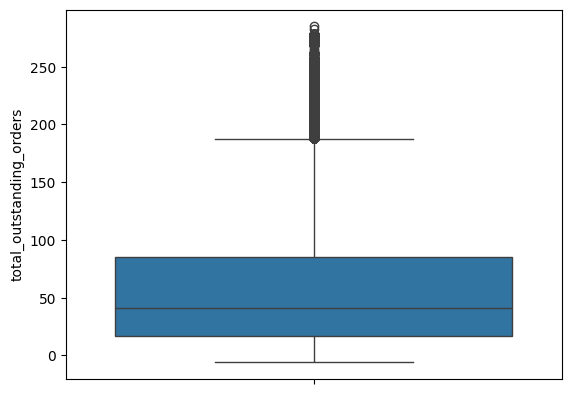

In [18]:
for i in num_cols:
  sns.boxplot(df[i])
  plt.show()

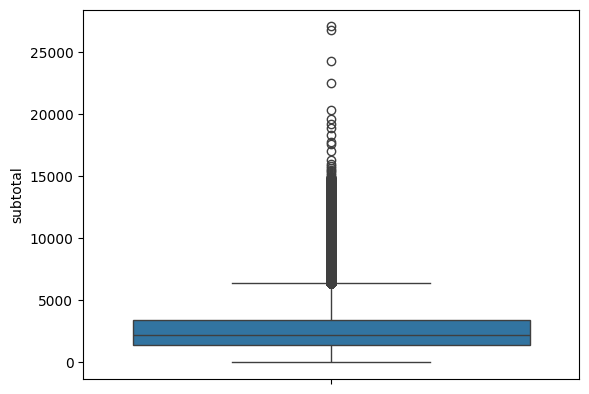

In [19]:
sns.boxplot(df['subtotal'])
plt.show()

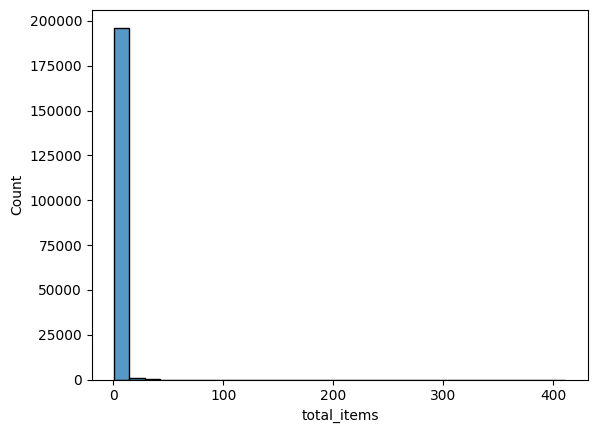

In [20]:
sns.histplot(df['total_items'], bins=30)
plt.show()

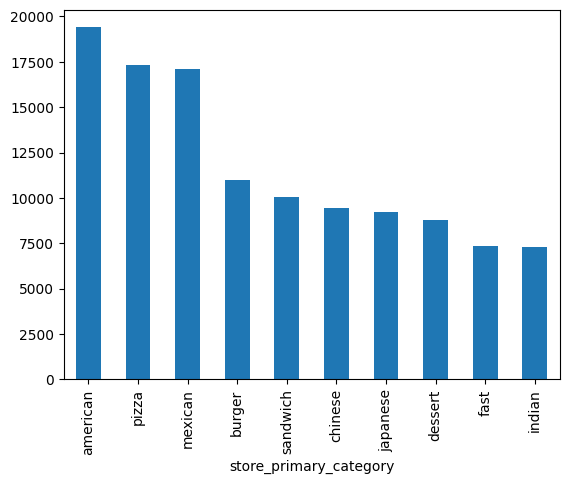

In [21]:
df['store_primary_category'].value_counts().head(10).plot(kind='bar')
plt.show()

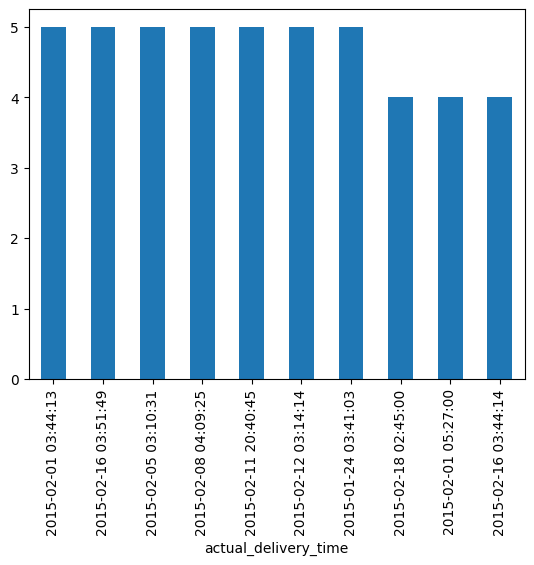

In [22]:
df['actual_delivery_time'].value_counts().head(10).plot(kind='bar')
plt.show()

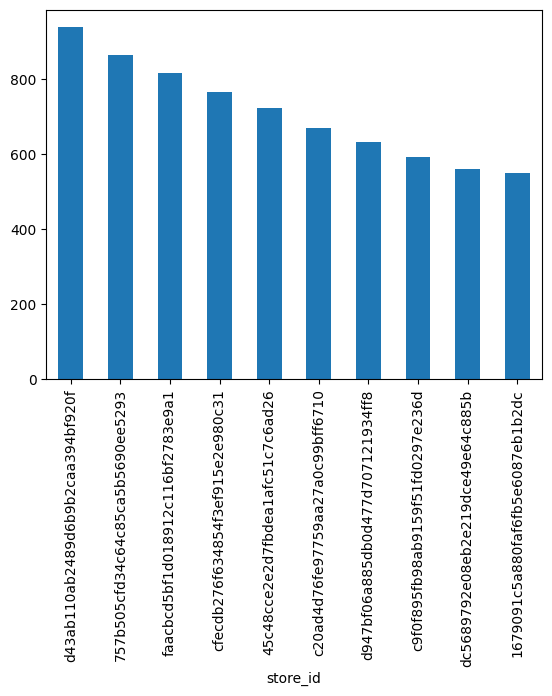

In [23]:
df['store_id'].value_counts().head(10).plot(kind='bar')
plt.show()

In [24]:
df['created_at'] = pd.to_datetime(df['created_at'],errors='coerce')
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'],errors='coerce')



In [25]:
# Target column (in minutes)
df['delivery_time'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60

In [26]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_time
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,62.983333
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,67.066667
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,29.683333
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,51.250000
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,39.833333


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   market_id                 196441 non-null  float64       
 1   created_at                197428 non-null  datetime64[ns]
 2   actual_delivery_time      197421 non-null  datetime64[ns]
 3   store_id                  197428 non-null  object        
 4   store_primary_category    192668 non-null  object        
 5   order_protocol            196433 non-null  float64       
 6   total_items               197428 non-null  int64         
 7   subtotal                  197428 non-null  int64         
 8   num_distinct_items        197428 non-null  int64         
 9   min_item_price            197428 non-null  int64         
 10  max_item_price            197428 non-null  int64         
 11  total_onshift_partners    181166 non-null  float64       
 12  to

In [28]:
# Categorical
df['store_primary_category'].fillna(df['store_primary_category'].mode()[0], inplace=True)
df['order_protocol'].fillna(df['order_protocol'].mode()[0], inplace=True)



In [29]:
# Numerical
num_cols_encode = ['total_onshift_partners', 'total_busy_partners', 'total_outstanding_orders']

for col in num_cols_encode:
    df[col].fillna(df[col].median(), inplace=True)

In [30]:
columns=df.select_dtypes(include=["int","float"]).columns

In [31]:
for i in columns:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    upper_whisker = Q3 + 1.5 * IQR
    lower_whisker = Q1 - 1.5 * IQR
    median = df[i].median()
    idx = df[(df[i] > upper_whisker) | (df[i] < lower_whisker)].index
    df[i].iloc[idx] = median

In [32]:
# def remove_outliers(df, col):
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR

#     return df[(df[col] >= lower) & (df[col] <= upper)]

# df = remove_outliers(df, 'subtotal')
# df = remove_outliers(df, 'total_items')
# df = remove_outliers(df, 'market_id')
# df = remove_outliers(df, 'market_id')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   market_id                 196441 non-null  float64       
 1   created_at                197428 non-null  datetime64[ns]
 2   actual_delivery_time      197421 non-null  datetime64[ns]
 3   store_id                  197428 non-null  object        
 4   store_primary_category    197428 non-null  object        
 5   order_protocol            197428 non-null  float64       
 6   total_items               197428 non-null  int64         
 7   subtotal                  197428 non-null  int64         
 8   num_distinct_items        197428 non-null  int64         
 9   min_item_price            197428 non-null  int64         
 10  max_item_price            197428 non-null  int64         
 11  total_onshift_partners    197428 non-null  float64       
 12  to

In [34]:
df.isna().sum()

,0
market_id,987
created_at,0
actual_delivery_time,7
store_id,0
store_primary_category,0
order_protocol,0
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0


In [35]:
df['delivery_time']=df['delivery_time'].fillna(df['delivery_time'].mean())

In [36]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.1 MB/s eta 0:00:00


In [37]:
from category_encoders import TargetEncoder

encoder = TargetEncoder()

cols = ['store_id','store_primary_category']
df[cols] = encoder.fit_transform(df[cols], df['delivery_time'])

In [38]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_time
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,47.904721,45.864854,1.0,4,3441,4,557,1239,33.0,14.0,21.0,62.983333
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,44.195178,43.214718,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,67.066667
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,44.195178,45.864854,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,29.683333
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,44.195178,45.864854,1.0,6,2200,5,600,1800,1.0,1.0,2.0,51.250000
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,44.195178,45.864854,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,39.833333


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   market_id                 196441 non-null  float64       
 1   created_at                197428 non-null  datetime64[ns]
 2   actual_delivery_time      197421 non-null  datetime64[ns]
 3   store_id                  197428 non-null  float64       
 4   store_primary_category    197428 non-null  float64       
 5   order_protocol            197428 non-null  float64       
 6   total_items               197428 non-null  int64         
 7   subtotal                  197428 non-null  int64         
 8   num_distinct_items        197428 non-null  int64         
 9   min_item_price            197428 non-null  int64         
 10  max_item_price            197428 non-null  int64         
 11  total_onshift_partners    197428 non-null  float64       
 12  to

In [40]:
df.isna().sum()

,0
market_id,987
created_at,0
actual_delivery_time,7
store_id,0
store_primary_category,0
order_protocol,0
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0


In [41]:
df['order_protocol'].value_counts()

,count
order_protocol,
1.0,55720
3.0,53199
5.0,44290
2.0,24052
4.0,19354
6.0,794
7.0,19


In [42]:
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()

# df['store_primary_category'] = le.fit_transform(df['store_primary_category'])
# df['store_id'] = le.fit_transform(df['store_id'])

In [43]:
# df = pd.get_dummies(df, columns=['store_primary_category', 'order_protocol'], drop_first=True)

In [44]:
df.drop(['market_id','store_id','created_at', 'actual_delivery_time'], axis=1, inplace=True)

In [45]:
df

,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_time
0,45.864854,1.0,4,3441,4,557,1239,33.0,14.0,21.0,62.983333
1,43.214718,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,67.066667
2,45.864854,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,29.683333
3,45.864854,1.0,6,2200,5,600,1800,1.0,1.0,2.0,51.250000
4,45.864854,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,39.833333
...,...,...,...,...,...,...,...,...,...,...,...
197423,41.970551,4.0,3,1389,3,345,649,17.0,17.0,23.0,65.116667
197424,41.970551,4.0,6,3010,4,405,825,12.0,11.0,14.0,56.383333
197425,41.970551,4.0,5,1836,3,300,399,39.0,41.0,40.0,50.133333
197426,43.199975,1.0,1,1175,1,535,535,7.0,7.0,12.0,65.116667


In [46]:
# from sklearn.model_selection import train_test_split

# X = df.drop('delivery_time', axis=1)
# y = df['delivery_time']

# X_train, X_test, y_train, y_test=(
#     train_test_split(X, y, test_size=0.2, random_state=42)
# )

In [47]:
from sklearn.model_selection import train_test_split
X = df.drop('delivery_time', axis=1)
y = df['delivery_time']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [48]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train_Sc = scaler.fit_transform(X_train)
# X_test_Sc = scaler.transform(X_test)

In [49]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [50]:
X_train

array([[-0.98343455, -0.57972553, -0.53838762, ..., -1.3983023 ,
        -1.37196173, -1.2290291 ],
       [-0.55671592, -0.57972553, -0.53838762, ...,  1.21396111,
         0.84329241,  0.62211665],
       [ 1.23722599, -1.24394276, -0.53838762, ...,  0.71160276,
         0.9125191 ,  0.99234579],
       ...,
       [ 0.10732525,  0.0844917 , -0.53838762, ...,  0.30971608,
         0.32409222,  0.69616248],
       [-0.57425831,  0.0844917 , -1.200636  , ..., -0.12566115,
         0.84329241,  0.7702083 ],
       [ 0.11085686, -1.24394276, -0.53838762, ..., -0.15915171,
        -0.19510797, -0.21706943]])

In [51]:
print("Training set " , X_train.shape)
print("Validation set " , X_val.shape)
print("Testing set " , X_test.shape)


Training set  (157942, 10)
Validation set  (19743, 10)
Testing set  (19743, 10)


### Creating a NN


In [52]:
model1=Sequential([
    Dense(256 , activation="relu" ,input_shape=(X_train.shape[1],)),
    Dense(128 , activation="relu"),
    Dense(64 , activation="relu"),
    Dense(32 , activation="relu"),
    Dense(1 , activation="linear")
])

In [53]:
for params in model1.weights:
  print(params.shape)

(10, 256)
(256,)
(256, 128)
(128,)
(128, 64)
(64,)
(64, 32)
(32,)
(32, 1)
(1,)


In [54]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,081 (180.00 KB)

 Trainable params: 46,081 (180.00 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model1.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [56]:
from tensorflow.keras.callbacks import EarlyStopping
Early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
model=model1.fit(X_train,y_train,epochs=50, batch_size=36 ,validation_data=(X_val,y_val), callbacks=[Early_stopping])

Epoch 1/50
3909/4388 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 280.8193 - mae: 12.6980

KeyboardInterrupt: 

In [57]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Activation
from tensorflow.keras.activations import relu , tanh , sigmoid
from tensorflow.keras.layers import Dropout

In [58]:
model2=Sequential([
    Dense(256 ,input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.2),

    Dense(128),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.2),

    Dense(64),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.2),

    Dense(32),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.2),

    Dense(1 , activation="linear")
])

In [59]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,001 (187.50 KB)

 Trainable params: 47,041 (183.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [60]:
model2.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [61]:
from tensorflow.keras.callbacks import EarlyStopping
Early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
model=model2.fit(X_train,y_train,epochs=50, batch_size=36 ,validation_data=(X_val,y_val), callbacks=[Early_stopping])

Epoch 1/50
4388/4388 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 402.3380 - mae: 15.1143 - val_loss: 178.9705 - val_mae: 10.5451
Epoch 2/50
4388/4388 ━━━━━━━━━━━━━━━━━━━━ 72s 12ms/step - loss: 210.0683 - mae: 11.4657 - val_loss: 176.0643 - val_mae: 10.4621
Epoch 3/50
4388/4388 ━━━━━━━━━━━━━━━━━━━━ 37s 8ms/step - loss: 203.9129 - mae: 11.2819 - val_loss: 174.4671 - val_mae: 10.4402
Epoch 4/50
4388/4388 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 200.8534 - mae: 11.2156 - val_loss: 174.9562 - val_mae: 10.3711
Epoch 5/50
4388/4388 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 198.8169 - mae: 11.1408 - val_loss: 174.4954 - val_mae: 10.4576
Epoch 6/50
4388/4388 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - loss: 197.2279 - mae: 11.1092 - val_loss: 173.6733 - val_mae: 10.3838
Epoch 7/50
4388/4388 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - loss: 195.0235 - mae: 11.0370 - val_loss: 173.1501 - val_mae: 10.4461
Epoch 8/50
4388/4388 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - loss: 193.8858 - mae: 11.0214 - val_loss: 172.4093 - 

KeyboardInterrupt: 

In [62]:
L2Reg = tf.keras.regularizers.L2(l2=1e-4)
model3 = Sequential([

    Dense(256 , kernel_regularizer=L2Reg,input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.2),

    Dense(128,kernel_regularizer=L2Reg),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.2),

    Dense(64,kernel_regularizer=L2Reg),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.2),

    Dense(32,kernel_regularizer=L2Reg),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.2),

    Dense(1 , activation="linear")
    ])

In [63]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,001 (187.50 KB)

 Trainable params: 47,041 (183.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [78]:
EarlyStoppingCallback = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                                         mode='max',
                                                         patience=10,
                                                         restore_best_weights=True)


ModelCheckpointCallback = tf.keras.callbacks.ModelCheckpoint(
                                    filepath='tf_model.h5',
                                    monitor='loss',
                                    save_best_only=True,
                                    mode='max')

In [79]:
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mae",
    metrics=["mae"]
)

In [80]:
model = model3.fit(X_train, y_train, validation_data=(X_val,y_val),
                    epochs=50, batch_size=36,
                     callbacks=[EarlyStoppingCallback, ModelCheckpointCallback])

Epoch 1/50
4384/4388 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11.1189 - mae: 10.5083

4388/4388 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 11.0170 - mae: 10.4882 - val_loss: 10.5880 - val_mae: 10.1856
Epoch 2/50
4388/4388 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 10.8269 - mae: 10.4912 - val_loss: 10.4881 - val_mae: 10.2042
Epoch 3/50
4388/4388 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 10.7385 - mae: 10.4882 - val_loss: 10.4417 - val_mae: 10.2186
Epoch 4/50
4388/4388 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - loss: 10.7086 - mae: 10.5057 - val_loss: 10.4075 - val_mae: 10.2219
Epoch 5/50
4388/4388 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 10.6653 - mae: 10.4918 - val_loss: 10.3725 - val_mae: 10.2102
Epoch 6/50
4388/4388 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 10.6509 - mae: 10.4969 - val_loss: 10.3568 - val_mae: 10.2109
Epoch 7/50
4388/4388 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 10.6469 - mae: 10.5070 - val_loss: 10.3497 - val_mae: 10.2158
Epoch 8/50
4388/4388 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 10.6312 - mae: 10.5017 - val_loss: 10.3479 - val_mae: 10.2224
Epoch 9/50


In [72]:
model3.evaluate(X_train,y_train)

4936/4936 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 170.6190 - mae: 10.3209


[170.61904907226562, 10.320935249328613]

In [69]:
model3.evaluate(X_val,y_val)

617/617 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 168.9758 - mae: 10.2905


[168.975830078125, 10.290496826171875]

In [70]:
model3.evaluate(X_test,y_test)

617/617 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 170.2089 - mae: 10.3281


[170.20887756347656, 10.328064918518066]

In [81]:
plt.figure(figsize=(7,5))

plt.plot(range(0, params['epochs']), history['loss'], label='Training', color='g')
plt.plot(range(0, params['epochs']), history['val_loss'], label='Validation', color='r')

plt.title('Loss vs. Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend()

plt.show()

TypeError: Only integers, slices (`:`), ellipsis (`...`), tf.newaxis (`None`) and scalar tf.int32/tf.int64 tensors are valid indices, got 'epochs'

<Figure size 700x500 with 0 Axes>